Make a plot of planetary radius as a function of equilibrium temperature and investigate whether there is a clear transition where inflation becomes significant.

In [172]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import ascii
import csv

In [173]:
temps = []
radii = []
sm_as = []
names = []
st_lums = []
st_masss = []
st_mets = []
st_rads = []

# temp_uncs = {
#     "plus" : plus,

# }

with open("PSCompPars_2026(1485).csv", newline='') as file:
    for line in file:
        if not line.startswith("#"):  # first non-metadata line
            header_line = line
            break

    reader = csv.DictReader(file, fieldnames=header_line.strip().split(","))
    # print(reader.fieldnames)

    for row in reader:
        if row["pl_eqt"] and row["pl_radj"] and row["st_lum"] and row["st_mass"] and row["st_met"] and row["pl_orbsmax"] and row["pl_name"] and row["st_rad"]:
            temps.append(float(row["pl_eqt"]))
            radii.append(float(row["pl_radj"]))
            sm_as.append(float(row["pl_orbsmax"]))
            st_lums.append(float(row["st_lum"]))
            st_masss.append(float(row["st_mass"]))
            st_mets.append(float(row["st_met"]))
            st_rads.append(float(row["st_rad"]))
            names.append(row["pl_name"])

In [174]:
J_temp = 122
J_rad = 1

In [175]:
def plot1(temp, rad):
    plt.figure(figsize=(12,8))
    plt.scatter(temp, rad, s=10)

    plt.scatter(J_temp, J_rad, color="red", s=10, label="Jupiter")

    x = np.linspace(min(temp), max(temp), 200)
    y = (1.1 * x ** 0.35) / 11
    plt.plot(x, y, linestyle="-", color="black", label="Inflation model")

    plt.xlabel("Equilibrium Temperature (°K)")
    plt.ylabel("Planetary Radius ($J_{rad}$)")
    plt.title("Figure 1")

    plt.legend()
    plt.show()


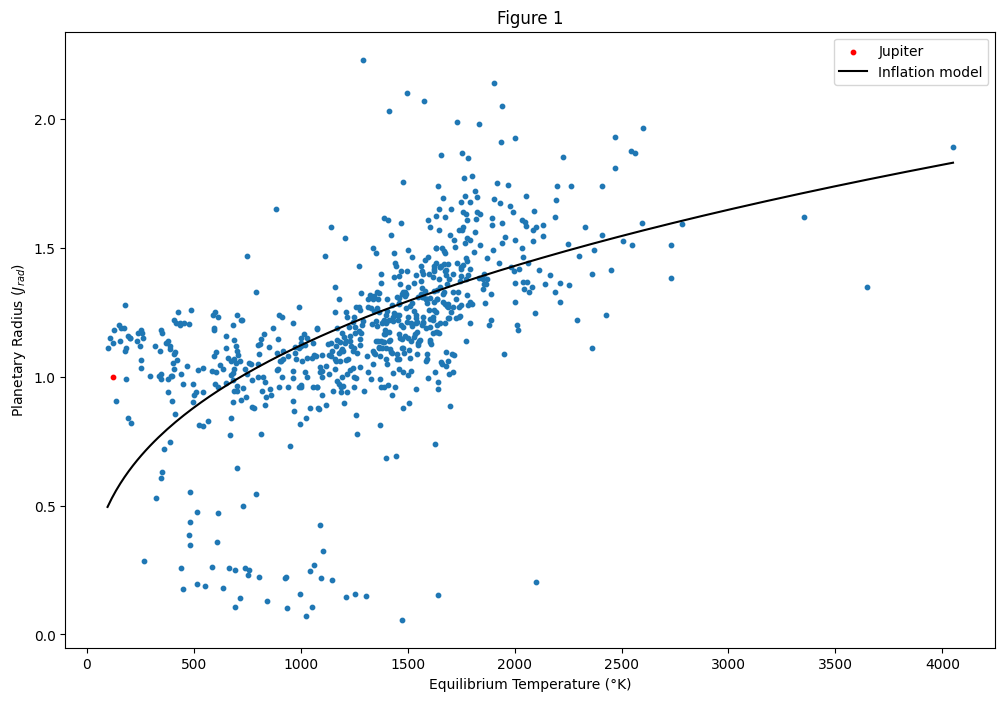

In [176]:
plot1(temps, radii)

How does the degree of inflation depend on incident flux?

In [177]:

# print(f"{len(temps)=}")
# print(f"{len(radii)=}")
# print(f"{len(names)=}")
# print(f"{len(st_lums)=}")
# print(f"{len(st_masss)=}")
# print(f"{len(st_mets)=}")

# # degree_of_inflation = 100*(int($J_{rad}$) - 1) # Or just the radius
# # incident_flux = L/(4*Pi*r^2)

In [178]:
def plot2(flux, percent, xaxis, yaxis):
    plt.figure(figsize=(12,8))
    plt.scatter(flux, percent, s=10)

    plt.xlabel(xaxis)
    plt.ylabel(yaxis)
    plt.title("Figure 2")

    plt.show()


In [ ]:
fluxes = []
distances = []
increase_percent = []

for pl_rad, st_rad, sm_a in zip(radii, st_rads, sm_as):
    dist = sm_a - (st_rad + pl_rad)
    distances.append(dist)

# for dist in distances:
#     if dist == min(distances):
#         print(f"minimum {dist=}")

# for lum in st_lums:
#     if lum == max(st_lums):
#         print(f"maximum {lum=}")

for dist, lum in zip(distances, st_lums):
    flux = lum / (4 * np.pi * dist ** 2)
    fluxes.append(flux)

# for flux in fluxes:
#     if flux == max(fluxes):
#         print(f"maximum {flux=}")
#         print("supposed lum.")
#         print(flux * (4 * np.pi * dist ** 2))
#         print("supposed dist.")
#         print(np.sqrt(lum / (flux * 4 * np.pi)))

for temp, rad in zip(temps, radii):
    exp_rad = (1.1 * temp ** 0.35) / 11 # /11 to convert to Jupiter Radius
    increase = ((rad / exp_rad) - 1) * 100 # *100 to get a percentage
    increase_percent.append(increase)

    # print(rad)
    # print(temp)
    # print(exp_rad)
    # print(increase)
    # print()

print(max(fluxes))
fluxes.remove(max(fluxes))
print(max(fluxes))
fluxes.remove(max(fluxes))
print(max(fluxes))

print()

print(min(fluxes))
# fluxes.remove(min(fluxes))
# print(min(fluxes))

113.55754158480828
9.126033758541142
0.10383645004251724
-20.54922416275041


<>:2: SyntaxWarning: invalid escape sequence '\c'
<>:2: SyntaxWarning: invalid escape sequence '\c'
C:\Users\macau\AppData\Local\Temp\ipykernel_53540\780367070.py:2: SyntaxWarning: invalid escape sequence '\c'
  plot2(fluxes, increase_percent, "Incidence Flux ($erg \cdot cm^{-2} \cdot s^{-1}$)", "Degree of Inflation from Expected Value (%)")


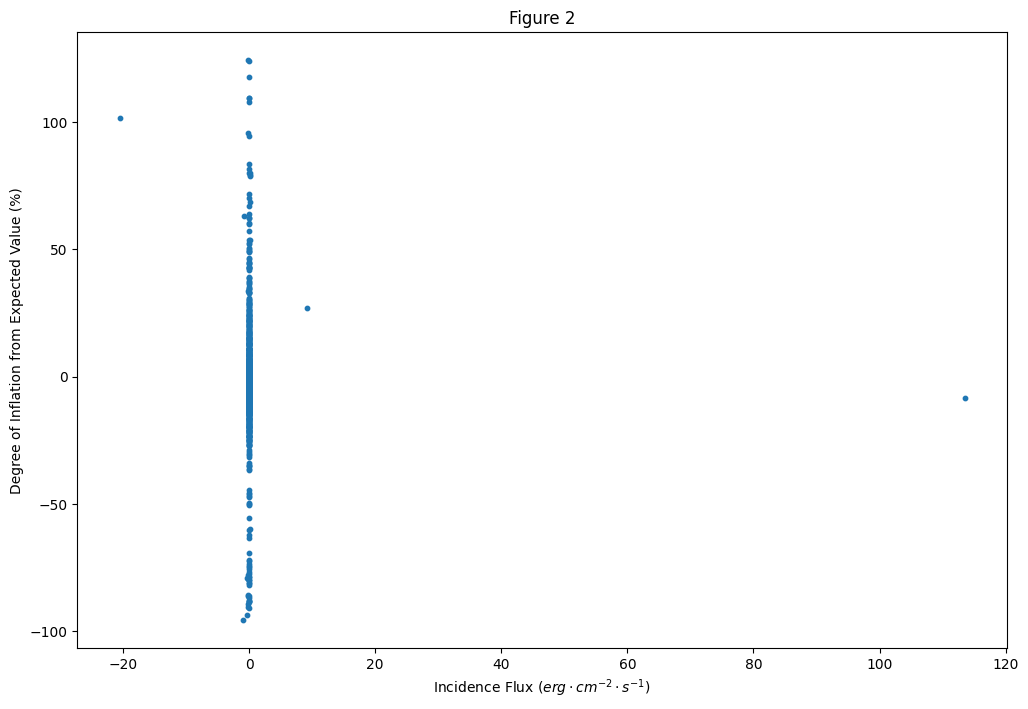

In [207]:
# plot2(fluxes, radii, "Incidence Flux ($erg \cdot cm^{-2} \cdot s^{-1}$)", "Planetary Radius ($J_{rad}$)")
plot2(fluxes, increase_percent, "Incidence Flux ($erg \cdot cm^{-2} \cdot s^{-1}$)", "Degree of Inflation from Expected Value (%)")